In [3]:
import tensorflow as tf 
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten,MaxPooling2D,Conv2D

In [4]:
import os

zip_path = r"C:\Users\Arjun Singh Tomar\Downloads\dogVscat.zip"

print(os.path.exists(zip_path))

True


In [5]:
import zipfile

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    print(zip_ref.namelist()[:10])

['catsvsdogs/test/cats/cat.10.jpg', 'catsvsdogs/test/cats/cat.10000.jpg', 'catsvsdogs/test/cats/cat.10001.jpg', 'catsvsdogs/test/cats/cat.10007.jpg', 'catsvsdogs/test/cats/cat.10017.jpg', 'catsvsdogs/test/cats/cat.10021.jpg', 'catsvsdogs/test/cats/cat.10026.jpg', 'catsvsdogs/test/cats/cat.10030.jpg', 'catsvsdogs/test/cats/cat.10033.jpg', 'catsvsdogs/test/cats/cat.10035.jpg']


In [6]:
extract_path = r"C:\Users\Arjun Singh Tomar\Downloads\cat_dog_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [7]:
print(os.listdir(extract_path)[:10])

['catsvsdogs', 'test', 'train']


In [8]:
train_ds = keras.utils.image_dataset_from_directory(
    directory=r"C:\Users\Arjun Singh Tomar\Downloads\cat_dog_dataset\train",
    labels="inferred",
    label_mode="int",
    batch_size=64,
    image_size=(128, 128),
    validation_split=0.2,
    subset="training",
    seed=42
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory=r"C:\Users\Arjun Singh Tomar\Downloads\cat_dog_dataset\train",
    labels="inferred",
    label_mode="int",
    batch_size=64,
    image_size=(128, 128),
    validation_split=0.2,
    subset="validation",
    seed=42
)


Found 20000 files belonging to 2 classes.
Using 16000 files for training.
Found 20000 files belonging to 2 classes.
Using 4000 files for validation.


In [9]:
# Normalize 

def process(image,label):
    image = tf.cast(image/255. , tf.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [10]:
# create cnn model 

model = Sequential()

model.add(Conv2D(32,kernel_size = (3,3),padding = 'valid',activation = 'relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(pool_size = (2,2),strides = 2,padding = 'valid'))

model.add(Conv2D(64,kernel_size = (3,3),padding = 'valid',activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2),strides = 2,padding = 'valid'))

model.add(Conv2D(128,kernel_size = (3,3),padding = 'valid',activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2),strides = 2,padding = 'valid'))

model.add(Flatten())

model.add(Dense(128,activation = 'relu'))
model.add(Dense(64,activation = 'relu'))
model.add(Dense(1,activation = 'sigmoid'))

C:\Users\Arjun Singh Tomar\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,312,961 (12.64 MB)

 Trainable params: 3,312,961 (12.64 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics  = ['accuracy']
)

In [13]:
model.fit(train_ds,epochs = 3,validation_data = validation_ds)

Epoch 1/3


C:\Users\Arjun Singh Tomar\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


250/250 ━━━━━━━━━━━━━━━━━━━━ 388s 2s/step - accuracy: 0.6446 - loss: 0.6194 - val_accuracy: 0.7327 - val_loss: 0.5261
Epoch 2/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 363s 1s/step - accuracy: 0.7606 - loss: 0.4940 - val_accuracy: 0.7950 - val_loss: 0.4403
Epoch 3/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 295s 1s/step - accuracy: 0.8049 - loss: 0.4259 - val_accuracy: 0.7832 - val_loss: 0.4540


In [14]:
# Way to reduce overfitting

# 1. Add more data
# 2. Data augmentation
# 3. L1/L2 Regulariztion
# 4. Dropout
# 5. Batch Norm
# 6. Reduce Complexity

In [18]:
img_path = r"C:\Users\Arjun Singh Tomar\Downloads\adorable-brown-white-basenji-dog-smiling-giving-high-five-isolated-white_346278-1657.webp"

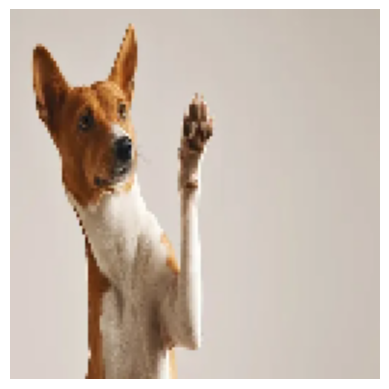

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
🐶 Dog


In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

img = tf.keras.utils.load_img(
    img_path,
    target_size=(128, 128)
)

plt.imshow(img)
plt.axis("off")
plt.show()

img_array = tf.keras.utils.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] < 0.5:
    print("🐱 Cat")
else:
    print("🐶 Dog")